In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('chip_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN
1,1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN
2,2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN
3,3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN
4,4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN


In [4]:
df.dtypes 

Unnamed: 0                 int64
Product                      str
Type                         str
Release Date                 str
Process Size (nm)        float64
TDP (W)                  float64
Die Size (mm^2)          float64
Transistors (million)    float64
Freq (MHz)               float64
Foundry                      str
Vendor                       str
FP16 GFLOPS              float64
FP32 GFLOPS              float64
FP64 GFLOPS              float64
dtype: object

In [ ]:
#dropping unnamed column
df1 = df.drop(columns=['Unnamed: 0'])

In [6]:
df1.head()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN
1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN
2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN
3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN
4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN


In [7]:
#check the missing values 
df1.isnull().sum()

Product                     0
Type                        0
Release Date                0
Process Size (nm)           9
TDP (W)                   626
Die Size (mm^2)           715
Transistors (million)     711
Freq (MHz)                  0
Foundry                     0
Vendor                      0
FP16 GFLOPS              4318
FP32 GFLOPS              2906
FP64 GFLOPS              3548
dtype: int64

In [8]:
missing_percent = df1.isnull().sum() / len(df1) * 100
print(missing_percent)

Product                   0.000000
Type                      0.000000
Release Date              0.000000
Process Size (nm)         0.185414
TDP (W)                  12.896580
Die Size (mm^2)          14.730119
Transistors (million)    14.647713
Freq (MHz)                0.000000
Foundry                   0.000000
Vendor                    0.000000
FP16 GFLOPS              88.957561
FP32 GFLOPS              59.868150
FP64 GFLOPS              73.094355
dtype: float64


In [9]:
#distribution of numerical variables
numeric_cols = df1.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
       'Transistors (million)', 'Freq (MHz)', 'FP16 GFLOPS', 'FP32 GFLOPS',
       'FP64 GFLOPS'],
      dtype='str')


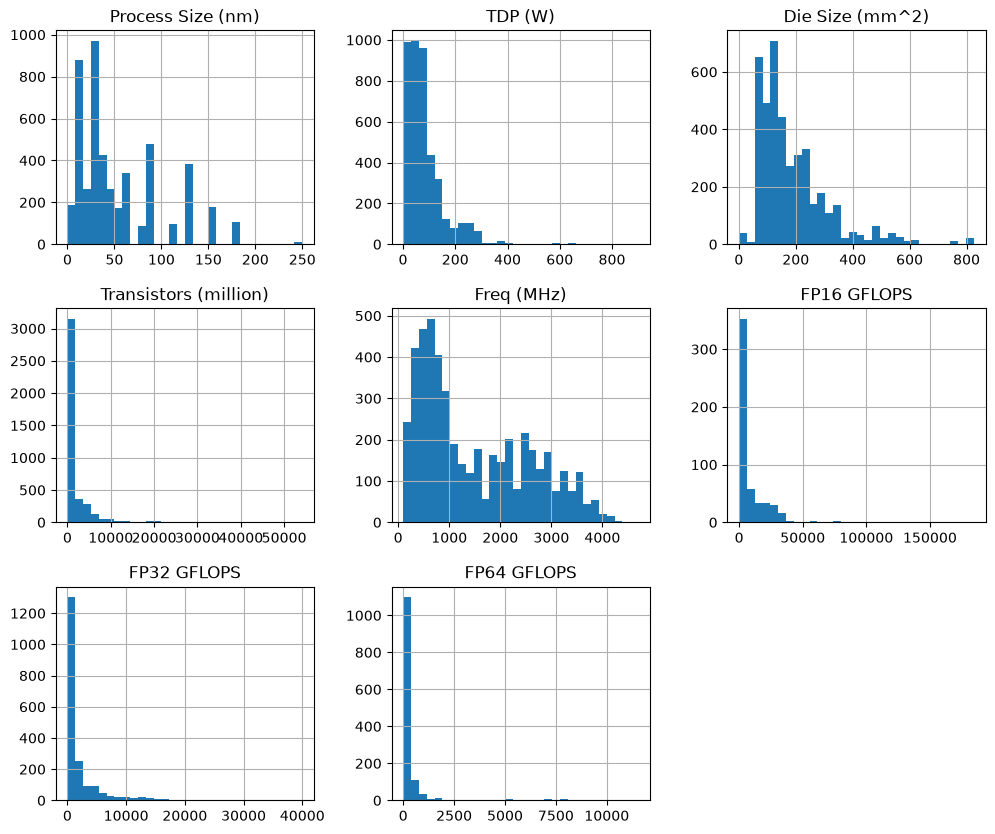

In [10]:
df1[numeric_cols].hist(figsize=(12, 10), bins=30)
plt.show()

In [11]:
#check categorical variables 
cat_col = df1.select_dtypes(include=['object']).columns
num_col = df1.select_dtypes(include=['int64', 'float64']).columns

print('Categorical columns:', list(cat_col))
print('Numerical columns:', list(num_col))

C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_9924\2736110559.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df1.select_dtypes(include=['object']).columns


Categorical columns: ['Product', 'Type', 'Release Date', 'Foundry', 'Vendor']
Numerical columns: ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']


In [13]:
#check unique values in categorical columns
df1[cat_col].nunique()

Product         4278
Type               2
Release Date    1357
Foundry           10
Vendor             5
dtype: int64

In [14]:
#convert release date 
df1['Release Date'] = pd.to_datetime(df1['Release Date'])

In [15]:
#check release date
df1['Release Date'].dtype

dtype('<M8[us]')

In [17]:
#handle missing values using mean imputation 
df1['Process Size (nm)'] = df1['Process Size (nm)'].fillna(
    df1['Process Size (nm)'].mean()
)

df1['TDP (W)'] = df1['TDP (W)'].fillna(
    df1['TDP (W)'].mean()
)

df1['Die Size (mm^2)'] = df1['Die Size (mm^2)'].fillna(
    df1['Die Size (mm^2)'].mean()
)

df1['Transistors (million)'] = df1['Transistors (million)'].fillna(
    df1['Transistors (million)'].mean()
)

In [18]:
#check missing values 
df1.isnull().sum()

Product                     0
Type                        0
Release Date               75
Process Size (nm)           0
TDP (W)                     0
Die Size (mm^2)             0
Transistors (million)       0
Freq (MHz)                  0
Foundry                     0
Vendor                      0
FP16 GFLOPS              4318
FP32 GFLOPS              2906
FP64 GFLOPS              3548
dtype: int64

In [19]:
#detect outliers using iqr 
Q1 = df1['TDP (W)'].quantile(0.25)
Q3 = df1['TDP (W)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -55.0
Upper bound: 185.0


In [20]:
#count the outliers 
outliers = df1[
    (df1['TDP (W)'] < lower_bound) |
    (df1['TDP (W)'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 380


C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_9924\459062263.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df1['TDP (W)'].dropna(), vert=False)


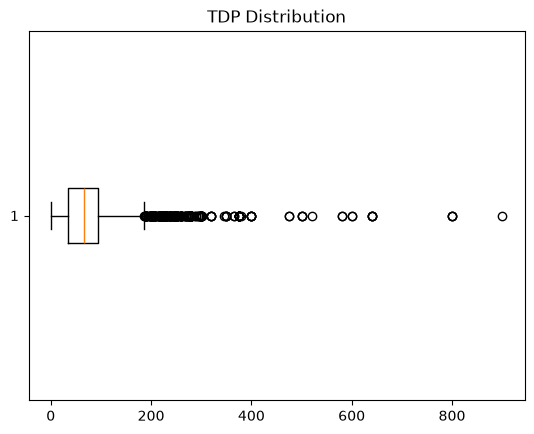

In [21]:
#visualize the outliers 
plt.boxplot(df1['TDP (W)'].dropna(), vert=False)
plt.title('TDP Distribution')
plt.show()

C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_9924\2878108084.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df1['Freq (MHz)'], vert=False)


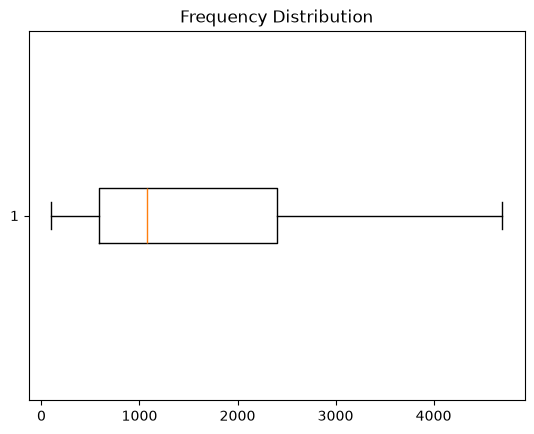

In [22]:
#major numerical values 
plt.boxplot(df1['Freq (MHz)'], vert=False)
plt.title('Frequency Distribution')
plt.show()

C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_9924\739497875.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df1['Transistors (million)'].dropna(), vert=False)


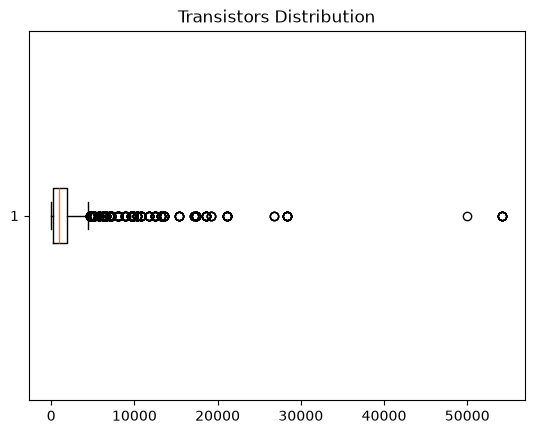

In [23]:
plt.boxplot(df1['Transistors (million)'].dropna(), vert=False)
plt.title('Transistors Distribution')
plt.show()

In [24]:
#Encoding
df2 = pd.get_dummies(
    df1,
    columns=['Type', 'Foundry', 'Vendor'],
    drop_first=True
)

In [25]:
df2.head()

,Product,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS,...,Foundry_Renesas,Foundry_Samsung,Foundry_Sony,Foundry_TSMC,Foundry_UMC,Foundry_Unknown,Vendor_ATI,Vendor_Intel,Vendor_NVIDIA,Vendor_Other
0,AMD Athlon 64 3500+,2007-02-20,65.0,45.0,77.000000,122.000000,2200.0,NaN,NaN,NaN,...,False,False,False,False,False,True,False,False,False,False
1,AMD Athlon 200GE,2018-09-06,14.0,35.0,192.000000,4800.000000,3200.0,NaN,NaN,NaN,...,False,False,False,False,False,True,False,False,False,False
2,Intel Core i5-1145G7,2020-09-02,10.0,28.0,188.440445,1929.922279,2600.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,True,False,False
3,Intel Xeon E5-2603 v2,2013-09-01,22.0,80.0,160.000000,1400.000000,1800.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,True,False,False
4,AMD Phenom II X4 980 BE,2011-05-03,45.0,125.0,258.000000,758.000000,3700.0,NaN,NaN,NaN,...,False,False,False,False,False,True,False,False,False,False


In [26]:
#check the new data types 
df2.dtypes

Product                             str
Release Date             datetime64[us]
Process Size (nm)               float64
TDP (W)                         float64
Die Size (mm^2)                 float64
Transistors (million)           float64
Freq (MHz)                      float64
FP16 GFLOPS                     float64
FP32 GFLOPS                     float64
FP64 GFLOPS                     float64
Type_GPU                           bool
Foundry_IBM                        bool
Foundry_Intel                      bool
Foundry_NEC                        bool
Foundry_Renesas                    bool
Foundry_Samsung                    bool
Foundry_Sony                       bool
Foundry_TSMC                       bool
Foundry_UMC                        bool
Foundry_Unknown                    bool
Vendor_ATI                         bool
Vendor_Intel                       bool
Vendor_NVIDIA                      bool
Vendor_Other                       bool
dtype: object

In [27]:
#convert boolean columns to int 
bool_cols = df2.select_dtypes(include='bool').columns

df2[bool_cols] = df2[bool_cols].astype(int)

In [28]:
#confirm the datatypes 
df2.dtypes

Product                             str
Release Date             datetime64[us]
Process Size (nm)               float64
TDP (W)                         float64
Die Size (mm^2)                 float64
Transistors (million)           float64
Freq (MHz)                      float64
FP16 GFLOPS                     float64
FP32 GFLOPS                     float64
FP64 GFLOPS                     float64
Type_GPU                          int64
Foundry_IBM                       int64
Foundry_Intel                     int64
Foundry_NEC                       int64
Foundry_Renesas                   int64
Foundry_Samsung                   int64
Foundry_Sony                      int64
Foundry_TSMC                      int64
Foundry_UMC                       int64
Foundry_Unknown                   int64
Vendor_ATI                        int64
Vendor_Intel                      int64
Vendor_NVIDIA                     int64
Vendor_Other                      int64
dtype: object

In [29]:
#Feature scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

In [ ]:
#using standard scaler
std_scaler = StandardScaler()

In [31]:
std_cols = [
    'Process Size (nm)',
    'Freq (MHz)'
]

In [32]:
df2[std_cols] = std_scaler.fit_transform(df2[std_cols])

In [33]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Product                4854 non-null   str           
 1   Release Date           4779 non-null   datetime64[us]
 2   Process Size (nm)      4854 non-null   float64       
 3   TDP (W)                4854 non-null   float64       
 4   Die Size (mm^2)        4854 non-null   float64       
 5   Transistors (million)  4854 non-null   float64       
 6   Freq (MHz)             4854 non-null   float64       
 7   FP16 GFLOPS            536 non-null    float64       
 8   FP32 GFLOPS            1948 non-null   float64       
 9   FP64 GFLOPS            1306 non-null   float64       
 10  Type_GPU               4854 non-null   int64         
 11  Foundry_IBM            4854 non-null   int64         
 12  Foundry_Intel          4854 non-null   int64         
 13  Foundry_NEC   

In [34]:
df2.isnull().sum()

Product                     0
Release Date               75
Process Size (nm)           0
TDP (W)                     0
Die Size (mm^2)             0
Transistors (million)       0
Freq (MHz)                  0
FP16 GFLOPS              4318
FP32 GFLOPS              2906
FP64 GFLOPS              3548
Type_GPU                    0
Foundry_IBM                 0
Foundry_Intel               0
Foundry_NEC                 0
Foundry_Renesas             0
Foundry_Samsung             0
Foundry_Sony                0
Foundry_TSMC                0
Foundry_UMC                 0
Foundry_Unknown             0
Vendor_ATI                  0
Vendor_Intel                0
Vendor_NVIDIA               0
Vendor_Other                0
dtype: int64

In [35]:
df2.describe()

,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS,Type_GPU,...,Foundry_Renesas,Foundry_Samsung,Foundry_Sony,Foundry_TSMC,Foundry_UMC,Foundry_Unknown,Vendor_ATI,Vendor_Intel,Vendor_NVIDIA,Vendor_Other
count,4779,4.854000e+03,4854.000000,4854.000000,4854.000000,4.854000e+03,536.000000,1948.000000,1306.000000,4854.000000,...,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000,4854.000000
mean,2011-03-26 17:07:29.717514,7.026381e-17,81.359981,188.440445,1929.922279,9.368507e-17,8397.459851,2134.756653,363.670511,0.548414,...,0.000206,0.012361,0.002060,0.448702,0.016275,0.178410,0.110218,0.286774,0.247425,0.013185
min,2000-01-01 00:00:00,-1.225957e+00,1.000000,1.000000,8.000000,-1.297972e+00,10.020000,12.800000,3.600000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006-08-26 12:00:00,-7.365496e-01,35.000000,112.000000,180.000000,-8.385647e-01,768.800000,257.300000,38.295000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2011-04-05 00:00:00,-3.361251e-01,67.000000,177.000000,950.000000,-3.852515e-01,2965.500000,696.000000,89.280000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2015-05-05 00:00:00,7.761650e-01,95.000000,221.000000,1929.922279,8.584297e-01,10600.000000,2116.750000,220.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2021-04-13 00:00:00,4.335493e+00,900.000000,826.000000,54200.000000,3.014831e+00,184600.000000,40000.000000,11540.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,1.000103e+00,71.683029,116.523337,3736.859205,1.000103e+00,13799.551131,3898.431487,1145.931856,0.497702,...,0.014353,0.110502,0.045347,0.497413,0.126545,0.382897,0.313194,0.452302,0.431560,0.114078


In [36]:
df2.head()

,Product,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS,...,Foundry_Renesas,Foundry_Samsung,Foundry_Sony,Foundry_TSMC,Foundry_UMC,Foundry_Unknown,Vendor_ATI,Vendor_Intel,Vendor_NVIDIA,Vendor_Other
0,AMD Athlon 64 3500+,2007-02-20,0.220020,45.0,77.000000,122.000000,0.670917,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
1,AMD Athlon 200GE,2018-09-06,-0.914516,35.0,192.000000,4800.000000,1.608482,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
2,Intel Core i5-1145G7,2020-09-02,-1.003499,28.0,188.440445,1929.922279,1.045943,NaN,NaN,NaN,...,0,0,0,0,0,0,0,1,0,0
3,Intel Xeon E5-2603 v2,2013-09-01,-0.736550,80.0,160.000000,1400.000000,0.295890,NaN,NaN,NaN,...,0,0,0,0,0,0,0,1,0,0
4,AMD Phenom II X4 980 BE,2011-05-03,-0.224896,125.0,258.000000,758.000000,2.077265,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
